<a href="https://colab.research.google.com/github/emeskuhmar-ux/HomeWorks/blob/main/Task_1_APML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

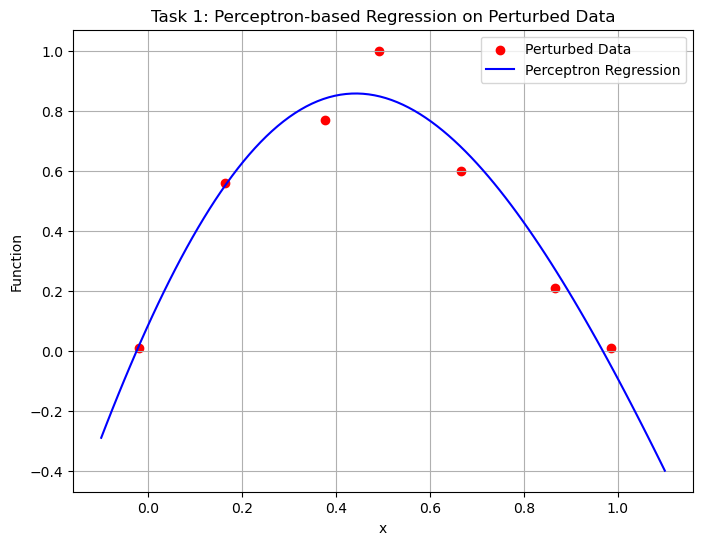

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def softplus(x):
    """Computes the activation function: f(xi) = ln(1 + e^xi)"""
    return np.log(1.0 + np.exp(x))

def d_softplus(x):
    """Computes its derivative: f'(xi) = e^xi / (1 + e^xi)"""
    return np.exp(x) / (1.0 + np.exp(x))

def branch_with_derivative(x, w1, b1, w2, b2):
    """Inside one branch: affine transformation -> activation -> linear output"""
    xi = x * w1 + b1
    y = softplus(xi)
    eta = w2 * y + b2
    dy = d_softplus(xi)
    return eta, dy, y

def model(x, w, b):
    """Full model F(x) is the sum of two parallel softplus branches"""

    eta1, _, _ = branch_with_derivative(x, w[0], b[0], w[1], b[1])

    eta2, _, _ = branch_with_derivative(x, w[2], b[2], w[3], b[3])
    return eta1 + eta2

def compute_loss(inputs, targets, w, b):
    """Calculates the sum of squared residuals R"""
    R = 0.0
    for i in range(len(inputs)):
        pred = model(inputs[i], w, b)
        R += (targets[i] - pred) ** 2
    return R

def train(inputs, targets, learning_rate, iterations):
    """Executes the gradient descent training loop"""

    w = [2.74, 0.36, -1.13, 0.63]
    b = [0.0, 0.0, 0.0, 0.0]

    for epoch in range(iterations):

        dw = [0.0, 0.0, 0.0, 0.0]
        db = [0.0, 0.0, 0.0, 0.0]


        for i in range(len(inputs)):
            x = inputs[i]
            target = targets[i]


            eta1, dy1, y1 = branch_with_derivative(x, w[0], b[0], w[1], b[1])
            eta2, dy2, y2 = branch_with_derivative(x, w[2], b[2], w[3], b[3])

            pred = eta1 + eta2
            error = target - pred


            dw[0] -= 2.0 * error * w[1] * dy1 * x
            db[0] -= 2.0 * error * w[1] * dy1
            dw[1] -= 2.0 * error * y1
            db[1] -= 2.0 * error

            dw[2] -= 2.0 * error * w[3] * dy2 * x
            db[2] -= 2.0 * error * w[3] * dy2
            dw[3] -= 2.0 * error * y2
            db[3] -= 2.0 * error


        for j in range(4):
            w[j] -= learning_rate * dw[j]
            b[j] -= learning_rate * db[j]

    return w, b




x_data = np.linspace(0, 1, 7)
phi_data = np.array([0.0, 0.55, 0.82, 1.0, 0.62, 0.21, 0.0,])

epsilon = 0.05
x_perturbed = x_data + np.random.uniform(-epsilon, epsilon, size=x_data.shape) # [cite: 493]
phi_perturbed = phi_data + np.random.uniform(-epsilon, epsilon, size=phi_data.shape)

lr = 0.01
epochs = 5000
w_trained, b_trained = train(x_perturbed, phi_perturbed, lr, epochs)

x_fine = np.linspace(-0.1, 1.1, 100)
y_pred = [model(xi, w_trained, b_trained) for xi in x_fine]

plt.figure(figsize=(8, 6))
plt.scatter(x_perturbed, phi_perturbed, color='red', label='Perturbed Data')
plt.plot(x_fine, y_pred, 'b-', label='Perceptron Regression')
plt.title("Task 1: Perceptron-based Regression on Perturbed Data")
plt.xlabel("x")
plt.ylabel("Function")
plt.legend()
plt.grid(True)
plt.show()

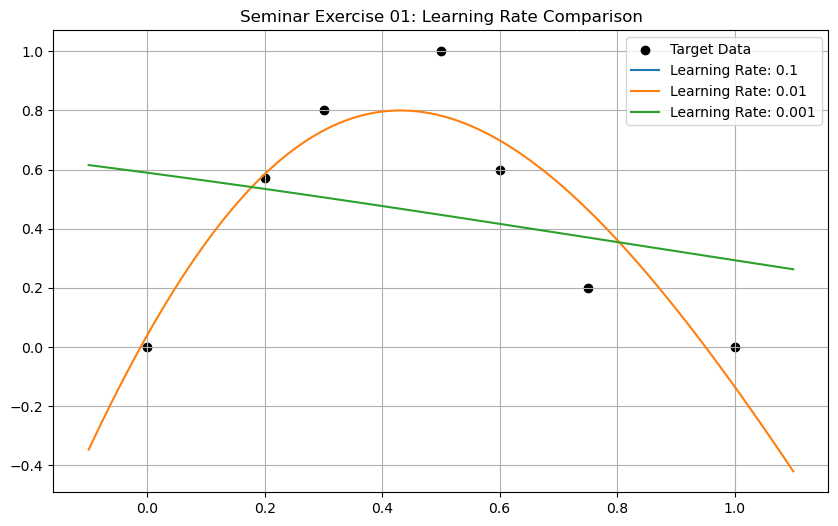

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def softplus(x):

    return np.log(1.0 + np.exp(x))

def d_softplus(x):

    return np.exp(x) / (1.0 + np.exp(x))

def branch_with_derivative(x, w1, b1, w2, b2):

    xi = x * w1 + b1
    y = softplus(xi)
    eta = w2 * y + b2
    dy = d_softplus(xi)
    return eta, dy, y

def model(x, w, b):

    eta1, _, _ = branch_with_derivative(x, w[0], b[0], w[1], b[1])
    eta2, _, _ = branch_with_derivative(x, w[2], b[2], w[3], b[3])
    return eta1 + eta2

def train(inputs, targets, learning_rate, iterations):

    w = [2.74, 0.36, -1.13, 0.63]
    b = [0.0, 0.0, 0.0, 0.0]

    for epoch in range(iterations):
        dw = [0.0, 0.0, 0.0, 0.0]
        db = [0.0, 0.0, 0.0, 0.0]

        for i in range(len(inputs)):
            x, target = inputs[i], targets[i]
            eta1, dy1, y1 = branch_with_derivative(x, w[0], b[0], w[1], b[1])
            eta2, dy2, y2 = branch_with_derivative(x, w[2], b[2], w[3], b[3])

            pred = eta1 + eta2
            error = target - pred
            dw[0] -= 2.0 * error * w[1] * dy1 * x
            db[0] -= 2.0 * error * w[1] * dy1
            dw[1] -= 2.0 * error * y1
            db[1] -= 2.0 * error
            dw[2] -= 2.0 * error * w[3] * dy2 * x
            db[2] -= 2.0 * error * w[3] * dy2
            dw[3] -= 2.0 * error * y2
            db[3] -= 2.0 * error

        for j in range(4):
            w[j] -= learning_rate * dw[j]
            b[j] -= learning_rate * db[j]

    return w, b


x_data = np.array([0.0, 0.2, 0.3, 0.5, 0.6, 0.75, 1.0])
phi_original = np.array([0.0, 0.57, 0.8, 1.0, 0.6, 0.2, 0.0])


lrs = [0.1, 0.01, 0.001]
plt.figure(figsize=(10, 6))
plt.scatter(x_data, phi_original, color='black', label='Target Data')

x_smooth = np.linspace(-0.1, 1.1, 100)

for lr in lrs:
    w_final, b_final = train(x_data, phi_original, lr, 5000)
    y_plot = [model(v, w_final, b_final) for v in x_smooth]
    plt.plot(x_smooth, y_plot, label=f'Learning Rate: {lr}')

plt.title("01: Learning Rate Comparison")
plt.legend()
plt.grid(True)
plt.show()

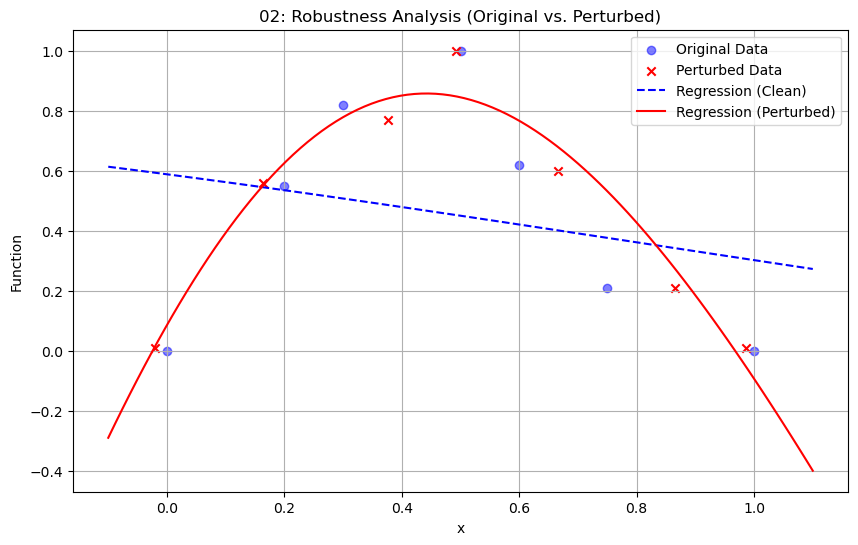

In [ ]:
# 1. Train on Clean Data
w_clean, b_clean = train(x_data, phi_data, lr, epochs)
y_pred_clean = [model(xi, w_clean, b_clean) for xi in x_fine]

# 2. Visual Comparison
plt.figure(figsize=(10, 6))

# Plot Original vs Perturbed Data Points
plt.scatter(x_data, phi_data, color='blue', label='Original Data', alpha=0.5)
plt.scatter(x_perturbed, phi_perturbed, color='red', marker='x', label='Perturbed Data')

# Plot Both Regression Curves
plt.plot(x_fine, y_pred_clean, 'b--', label='Regression (Clean)')
plt.plot(x_fine, y_pred, 'r-', label='Regression (Perturbed)')

plt.title("02: Robustness Analysis (Original vs. Perturbed)")
plt.xlabel("x")
plt.ylabel("Function")
plt.legend()
plt.grid(True)
plt.show()